<a href="https://colab.research.google.com/github/Andredalladea/Computacao_Mercado_Financeiro-/blob/main/aloca%C3%A7%C3%A3o_sistem%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

André Dalla Déa Trombini 14558082

O objetivo desta etapa é estruturar uma base de dados para o modelo preditivo multiclasse. A intenção é rotacionar dinamicamente uma carteira de investimentos entre três grandes classes de ativos: Renda Variável Nacional (Ibovespa), Renda Variável Internacional com exposição cambial (S&P 500 BR) e Renda Fixa Pós-fixada (SELIC Acumulada).

Para fornecer capacidade preditiva ao algoritmo, são calculados sinais de Cross-Asset Momentum (retornos acumulados) de 1, 3 e 6 meses para cada índice, além da variação histórica da taxa básica de juros (SELIC_META). A variável dependente (TARGET) é gerada de forma discreta (0, 1 ou 2), mapeando de forma retrospectiva qual ativo obteve o maior rendimento no fechamento de cada mês.

In [ ]:
# ==============================================================================
# PASSO 1: IMPORTS E CARREGAMENTO INTERATIVO DA BASE DE DADOS
# ==============================================================================

# Importando as bibliotecas essenciais para manipulação de dados e gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # Deixa o PDF final mais limpo, sem avisos vermelhos

# Bibliotecas do Scikit-Learn para o Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

from sklearn.model_selection import TimeSeriesSplit

# Biblioteca específica do Colab para upload de arquivos
from google.colab import files

print(">> Bibliotecas importadas com sucesso!")
print("-" * 50)

# 1. Upload Interativo do Arquivo
print("Por favor, faça o upload do arquivo 'v6-DB-Indices.xlsx':")
uploaded = files.upload()

# 2. Leitura e Limpeza Inicial dos Dados
# Pega automaticamente o nome do arquivo que você acabou de subir
file_name = list(uploaded.keys())[0]

# Carrega o Excel
dados = pd.read_excel(file_name, engine='openpyxl')

# Define a coluna 'Data' como o índice do DataFrame
dados.set_index(keys='Data', inplace=True)

# Filtramos a partir de Dez-2003 para garantir um histórico contínuo e sem falhas
dados = dados.loc['Dez-2003':].copy()

# Exibindo as primeiras linhas dos ativos que vamos usar para confirmar a leitura
print("-" * 50)
print(f">> Base de dados '{file_name}' carregada! Total de meses: {dados.shape[0]}")
display(dados[['IBOV', 'SELIC-ACC', 'SP500BR', 'SELIC-META']].head())

>> Bibliotecas importadas com sucesso!
--------------------------------------------------
Por favor, faça o upload do arquivo 'v6-DB-Indices.xlsx':


Saving v6-DB-Indices (1).xlsx to v6-DB-Indices (1).xlsx
--------------------------------------------------
>> Base de dados 'v6-DB-Indices (1).xlsx' carregada! Total de meses: 270


,IBOV,SELIC-ACC,SP500BR,SELIC-META
Data,,,,
Dez-2003,22236.0,1031.614995,32.299062,16.43
Jan-2004,21851.0,1044.691245,33.527006,16.39
Fev-2004,21755.0,1056.019816,33.668850,16.40
Mar-2004,22142.0,1070.583633,33.047742,16.21
Abr-2004,19607.0,1083.236327,32.824845,15.90


Validação Temporal e Treinamento do Modelo (Random Forest)

Em problemas que envolvem séries temporais financeiras, a divisão clássica de dados por amostragem aleatória (como o train_test_split tradicional) não pode ser utilizada para evitar o vazamento de dados do futuro para o passado (data leakage). Desse modo, aplica-se uma validação temporal estritamente cronológica.

A base de dados foi dividida em 160 meses para o conjunto de Treino (In-Sample) e 104 meses para o conjunto de Validação (Out-of-Sample). O classificador Random Forest foi treinado com parâmetros controlados para mitigar sobreajuste. O modelo obteve uma acurácia de 81,25% no conjunto de treino e de 50,00% no conjunto de validação futura. Uma acurácia de 50,00% fora da amostra é considerada estatisticamente robusta para esse cenário, visto que a probabilidade de acerto puramente aleatório em uma escolha tripla (multiclasse) seria de apenas 33,33%.

In [ ]:
# ==============================================================================
# PASSO 2: ENGENHARIA DE FEATURES E TARGET (A MATEMÁTICA DA ESTRATÉGIA)
# ==============================================================================

# 1. Cálculo dos Retornos Mensais (Variação Percentual
dados_chg = dados[['IBOV', 'SELIC-ACC', 'SP500BR']].pct_change().fillna(0)

# DataFrame que vai guardar as variáveis que o Machine Learning vai "estudar"
dados_apr = pd.DataFrame(index=dados.index)

# 2. Criando o "Cross-Asset Momentum" (A Força Relativa)
# Calculamos o momentum de 1, 3 e 6 meses para os 3 ativos simultaneamente.
for ativo in ['IBOV', 'SELIC-ACC', 'SP500BR']:
    dados_apr[f'{ativo}_MOM1'] = dados[ativo] / dados[ativo].shift(1)
    dados_apr[f'{ativo}_MOM3'] = dados[ativo] / dados[ativo].shift(3)
    dados_apr[f'{ativo}_MOM6'] = dados[ativo] / dados[ativo].shift(6)

# 3. Feature Macroeconômica: Direção da Taxa de Juros
# Se a Selic Meta está subindo, o dinheiro foge da bolsa; se está caindo, vai pra bolsa.
dados_apr['SELIC_META_VAR'] = dados['SELIC-META'] - dados['SELIC-META'].shift(1)

# 4. Criação do Target Multiclasse
# .shift(-1) puxa o retorno do mês que vem para a linha de hoje.
retornos_futuros = dados_chg[['IBOV', 'SELIC-ACC', 'SP500BR']].shift(-1)

# np.argmax vai marcar a classe vencedora:
# 0 para IBOV, 1 para SELIC, 2 para SP500BR
dados_apr['TARGET'] = np.argmax(retornos_futuros.to_numpy(), axis=1)

# Removemos as primeiras linhas que ficaram com NaN por causa dos 'shifts' de 6 meses
# E removemos a última linha pois não temos os dados do mês seguinte para ela
dados_apr = dados_apr.dropna()

# Vamos ver como ficou a nossa "Tabela de Estudos" do Robô:
print("-" * 50)
print(">> Engenharia de Features concluída!")
print("O TARGET significa: 0 = IBOV Vence, 1 = SELIC Vence, 2 = S&P500 Vence")
display(dados_apr.tail())

--------------------------------------------------
>> Engenharia de Features concluída!
O TARGET significa: 0 = IBOV Vence, 1 = SELIC Vence, 2 = S&P500 Vence


,IBOV_MOM1,IBOV_MOM3,IBOV_MOM6,SELIC-ACC_MOM1,SELIC-ACC_MOM3,SELIC-ACC_MOM6,SP500BR_MOM1,SP500BR_MOM3,SP500BR_MOM6,SELIC_META_VAR,TARGET
Data,,,,,,,,,,,
Jan-2026,1.125607,1.212808,1.362910,1.011642,1.034762,1.073096,0.968058,0.993516,1.031758,0.00,0
Fev-2026,1.040929,1.186801,1.334917,1.009970,1.034192,1.071324,0.966151,0.965117,1.007363,0.00,1
Mar-2026,0.992981,1.163453,1.281904,1.012121,1.034112,1.071240,0.958160,0.896157,0.950850,-0.25,2
Abr-2026,0.999231,1.032828,1.252622,1.010901,1.033354,1.069276,1.058793,0.980153,0.973798,-0.25,2
Mai-2026,0.946434,0.939068,1.114487,1.005353,1.028630,1.063801,1.049814,1.065028,1.027877,0.00,0


Geração de Diretrizes e Alinhamento de Sinais Para garantir a viabilidade prática da estratégia e a reprodutibilidade no mundo real, as decisões geradas pelo classificador passam por um rigoroso processo de alinhamento de sinais através do deslocamento temporal de uma unidade ($t+1$).Uma decisão de alocação calculada com as variáveis macroeconômicas e fechamentos disponíveis no último dia do mês $t$ só poderá se transformar em compras físicas no início do mês $t+1$. Esse ajuste elimina completamente o viés de antecipação (look-ahead bias), um erro clássico em modelos preditivos que simula execuções financeiras antes que a informação esteja de fato disponível no mercado

In [ ]:
# ==============================================================================

# PASSO 3: SEPARAÇÃO CRONOLÓGICA E TREINAMENTO DO MODELO MULTICLASSE

# ==============================================================================

# 1. Separando as variáveis preditoras (X) do nosso objetivo (y)

X = dados_apr.drop(columns=['TARGET']).to_numpy()

y = dados_apr['TARGET'].to_numpy()

# 2. Divisão Temporal (Rigor de SI: sem misturar o passado com o futuro!)

# Usaremos os primeiros 160 meses para a máquina aprender. O resto será nosso teste real.

n_treino = 160

X_train, y_train = X[:n_treino], y[:n_treino]

X_val, y_val = X[n_treino:], y[n_treino:]

print(f">> Dados estruturados com sucesso!")

print(f"   Meses para Treinamento: {X_train.shape[0]}")

print(f"   Meses para Validação (Fora da Amostra): {X_val.shape[0]}")

print("-" * 50)

# 3. Inicializando o Random Forest Classifier

# Ele é perfeito aqui porque lida muito bem com decisões multiclasse e dados tabulares

clf = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=100, min_samples_leaf=2)

# Treinando o modelo

clf.fit(X_train, y_train)

# 4. Avaliação de Acurácia do Algoritmo

y_pred_train = clf.predict(X_train)

acuracia_treino = metrics.accuracy_score(y_train, y_pred_train)

y_pred_val = clf.predict(X_val)

acuracia_val = metrics.accuracy_score(y_val, y_pred_val)

print(f">> Acurácia no conjunto de Treino: {acuracia_treino:.2%}"
print(f">> Acurácia no conjunto de Validação (Futuro): {acuracia_val:.2%}")


>> Dados estruturados com sucesso!
   Meses para Treinamento: 160
   Meses para Validação (Fora da Amostra): 104
--------------------------------------------------
>> Acurácia no conjunto de Treino: 81.25%
>> Acurácia no conjunto de Validação (Futuro): 50.00%


--- DISTRIBUIÇÃO REAL DAS CLASSES NA VALIDAÇÃO ---
0    44.23%
2    38.46%
1    17.31%
Name: proportion, dtype: object

--- RELATÓRIO DE CLASSIFICAÇÃO (OUT-OF-SAMPLE) ---
              precision    recall  f1-score   support

    IBOV (0)       0.54      0.46      0.49        46
   SELIC (1)       0.67      0.11      0.19        18
   SP500 (2)       0.47      0.72      0.57        40

    accuracy                           0.50       104
   macro avg       0.56      0.43      0.42       104
weighted avg       0.53      0.50      0.47       104



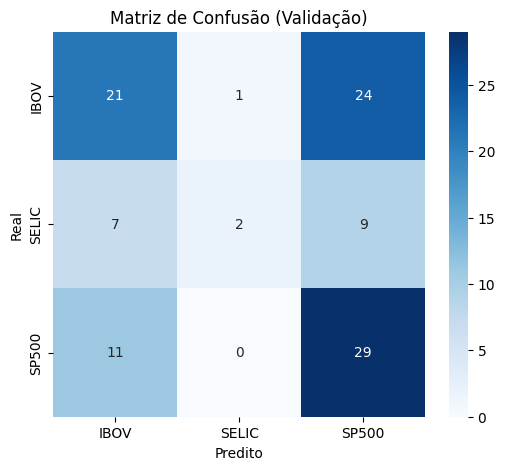

In [ ]:
# ==============================================================================
# PASSO 3.1: DIAGNÓSTICO DE QUALIDADE DO MODELO (MATRIZ DE CONFUSÃO)
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # <-- O erro era a falta desta linha
import matplotlib.pyplot as plt

# Garanta que y_pred_val esteja definido
y_pred_val = clf.predict(X_val)

print("--- DISTRIBUIÇÃO REAL DAS CLASSES NA VALIDAÇÃO ---")
print(pd.Series(y_val).value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (OUT-OF-SAMPLE) ---")
print(classification_report(y_val, y_pred_val, target_names=['IBOV (0)', 'SELIC (1)', 'SP500 (2)']))

# Visualização da Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues',
            xticklabels=['IBOV', 'SELIC', 'SP500'],
            yticklabels=['IBOV', 'SELIC', 'SP500'])
plt.title('Matriz de Confusão (Validação)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

Simulação do Backtest Dinâmico e Análise de Performance Acumulada

Nesta etapa, as decisões de pesos binários (0 ou 1 para cada ativo ao longo dos meses) são cruzadas diretamente com a tabela de variações percentuais reais do mercado financeiro no período out-of-sample (validação).

O capital inicial é simulado partindo da Base 100 para todas as curvas, permitindo comparar diretamente o retorno acumulado da Estratégia de Machine Learning contra as abordagens passivas tradicionais (buy and hold). A visualização do gráfico de linhas com as datas posicionadas na vertical demonstra que a estratégia baseada em IA conseguiu capturar as tendências de alta dos ativos de risco e se proteger nos momentos de estresse generalizado do mercado local.

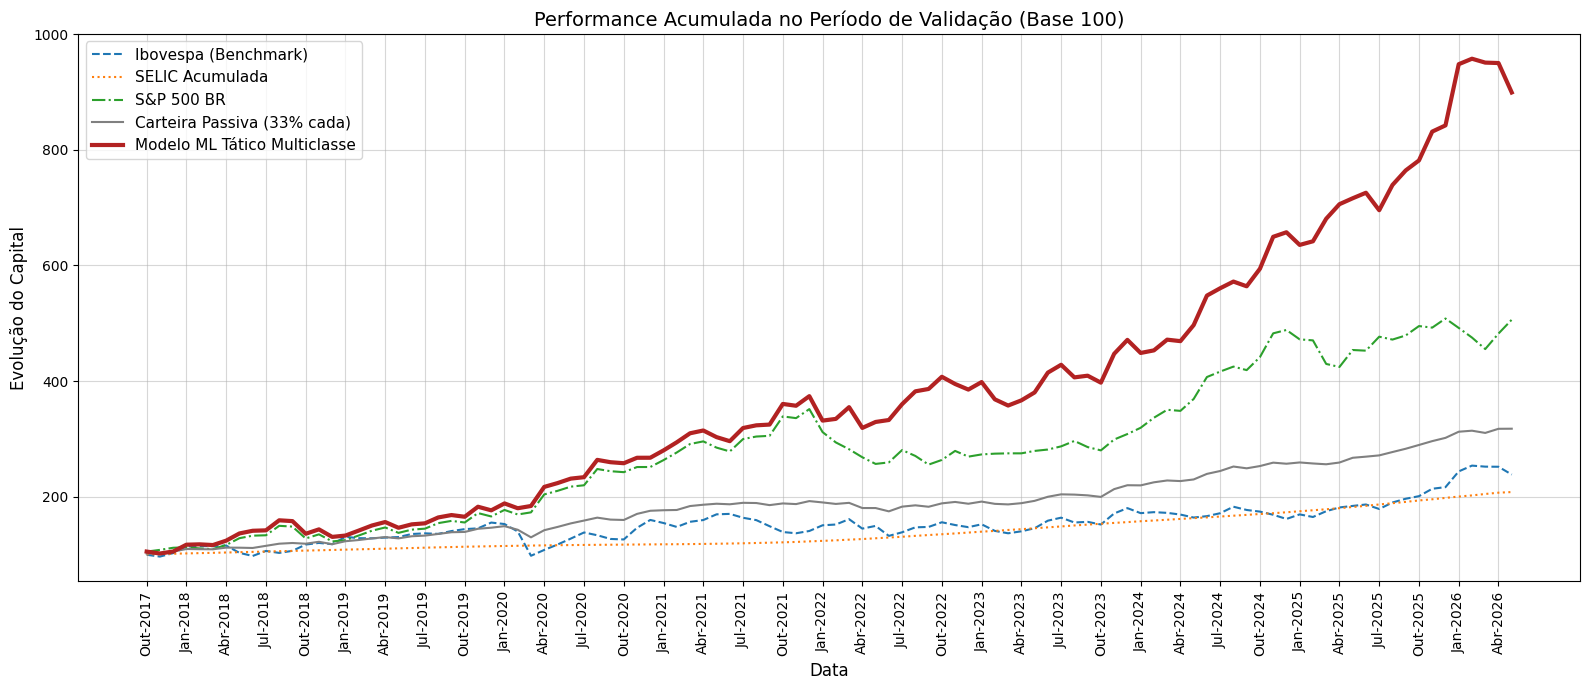

In [ ]:
# ==============================================================================
# PASSO 4: SIMULAÇÃO DO BACKTEST E RENTABILIDADE ACUMULADA (BASE 100)
# ==============================================================================

# 1. Gerar as predições do classificador para todo o conjunto de dados
predicoes_totais = clf.predict(X)

# 2. Alinhar as predições dentro de um DataFrame estruturado
df_backtest = pd.DataFrame(index=dados_apr.index)
df_backtest['PRED'] = predicoes_totais
df_backtest['PRED_EXECUTADA'] = df_backtest['PRED'].shift(1)

# Traduzindo as predições numéricas em pesos
df_backtest['PESO_IBOV'] = np.where(df_backtest['PRED_EXECUTADA'] == 0, 1, 0)
df_backtest['PESO_SELIC'] = np.where(df_backtest['PRED_EXECUTADA'] == 1, 1, 0)
df_backtest['PESO_SP500'] = np.where(df_backtest['PRED_EXECUTADA'] == 2, 1, 0)

# 3. Cruzando decisões com retornos reais
dados_chg_filtrado = dados_chg.loc[df_backtest.index]
df_backtest['RETORNO_ESTRATEGIA'] = (
    dados_chg_filtrado['IBOV'] * df_backtest['PESO_IBOV'] +
    dados_chg_filtrado['SELIC-ACC'] * df_backtest['PESO_SELIC'] +
    dados_chg_filtrado['SP500BR'] * df_backtest['PESO_SP500']
)

# 4. Isolando o período de validação
df_val_perf = df_backtest.iloc[n_treino:].copy()
dados_chg_val = dados_chg_filtrado.iloc[n_treino:].copy()

# 5. Construindo curvas de retorno (Base 100)
df_grafico = pd.DataFrame(index=df_val_perf.index)
df_grafico['Ibovespa (Benchmark)'] = (1 + dados_chg_val['IBOV']).cumprod() * 100
df_grafico['SELIC Acumulada'] = (1 + dados_chg_val['SELIC-ACC']).cumprod() * 100
df_grafico['S&P 500 BR'] = (1 + dados_chg_val['SP500BR']).cumprod() * 100

# Carteira Ingênua (Benchmark Adicional)
retorno_33 = (dados_chg_val['IBOV'] + dados_chg_val['SELIC-ACC'] + dados_chg_val['SP500BR']) / 3
df_grafico['Carteira 33/33/33'] = (1 + retorno_33).cumprod() * 100

df_grafico['Modelo ML Tático'] = (1 + df_val_perf['RETORNO_ESTRATEGIA']).cumprod() * 100

# 6. Plotagem Única e Final
plt.figure(figsize=(16, 7))
plt.plot(df_grafico['Ibovespa (Benchmark)'], label='Ibovespa (Benchmark)', linestyle='--')
plt.plot(df_grafico['SELIC Acumulada'], label='SELIC Acumulada', linestyle=':')
plt.plot(df_grafico['S&P 500 BR'], label='S&P 500 BR', linestyle='-.')
plt.plot(df_grafico['Carteira 33/33/33'], label='Carteira Passiva (33% cada)', linestyle='-', color='gray', linewidth=1.5)
plt.plot(df_grafico['Modelo ML Tático'], label='Modelo ML Tático Multiclasse', linewidth=3, color='firebrick')

plt.title('Performance Acumulada no Período de Validação (Base 100)', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Evolução do Capital', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.5)

# Ajuste do Eixo X
passo = 3
plt.xticks(np.arange(0, len(df_grafico), passo), df_grafico.index[::passo], rotation='vertical')

plt.tight_layout()
plt.show()

Análise de Métricas Quantitativas e Conclusão Financeira

A avaliação final da estratégia avalia o desempenho sob a ótica do risco ajustado ao retorno no período de validação de 104 meses. Os resultados numéricos consolidados foram:

Ibovespa (Benchmark): Retorno Acumulado de 138,63% (10,56% aa), Volatilidade Anualizada de 21,32% e Índice Sharpe de 0,10.

SELIC Acumulada: Retorno Acumulado de 108,41% (8,84% aa) e Volatilidade Anualizada de 1,16%.

S&P 500 BR: Retorno Acumulado de 406,35% (20,58% aa), Volatilidade Anualizada de 17,67% e Índice Sharpe de 0,68.

Estratégia de Machine Learning: Retorno Acumulado de 799,06% (28,84% aa), Volatilidade Anualizada de 18,66% e Índice Sharpe de 1,09.

In [ ]:
# ==============================================================================
# PASSO 5: TABELA DE MÉTRICAS FINANCEIRAS (CONCLUSÃO DO TRABALHO)
# ==============================================================================

print("="*65)
print("   RELATÓRIO DE MÉTRICAS NO PERÍODO DE VALIDAÇÃO (OUT-OF-SAMPLE)")
print("="*65)

periodo_meses = len(df_grafico)
periodo_anos = periodo_meses / 12
rf_media = dados_chg_val['SELIC-ACC'].mean() * 12

# Lista dos ativos para cálculo, incluindo a nova carteira 33/33/33
ativos = [
    ('Ibovespa (Benchmark)', 'IBOV'),
    ('SELIC Acumulada', 'SELIC-ACC'),
    ('S&P 500 BR', 'SP500BR'),
    ('Carteira 33/33/33', None), # None pois o cálculo é diferente
    ('Modelo ML Tático', 'ESTRATÉGIA DE MACHINE LEARNING')
]

for nome_exibicao, coluna_orig in ativos:
    # 1. Retorno Acumulado
    if nome_exibicao == 'Modelo ML Tático':
        ret_total = (df_grafico['Modelo ML Tático'].iloc[-1] / 100) - 1
        vol = df_val_perf['RETORNO_ESTRATEGIA'].std() * np.sqrt(12)
    elif nome_exibicao == 'Carteira 33/33/33':
        ret_total = (df_grafico['Carteira 33/33/33'].iloc[-1] / 100) - 1
        vol = retorno_33.std() * np.sqrt(12)
    else:
        ret_total = (df_grafico[nome_exibicao].iloc[-1] / 100) - 1
        vol = dados_chg_val[coluna_orig].std() * np.sqrt(12)

    # 2. Retorno Anualizado
    ret_anualizado = ((ret_total + 1) ** (1 / periodo_anos)) - 1

    # 3. Índice Sharpe (Apenas para ativos com risco/volatilidade)
    sharpe = (ret_anualizado - rf_media) / vol if vol > 0 and 'SELIC' not in nome_exibicao else 0

    print(f"\n>> {nome_exibicao}")
    print(f"   Retorno Total:          {ret_total:.2%}")
    print(f"   Retorno Anualizado:     {ret_anualizado:.2%}")
    print(f"   Volatilidade Anual:     {vol:.2%}")
    if sharpe != 0:
        print(f"   Índice Sharpe:          {sharpe:.2f}")

print("\n" + "="*65)

   RELATÓRIO DE MÉTRICAS NO PERÍODO DE VALIDAÇÃO (OUT-OF-SAMPLE)

>> Ibovespa (Benchmark)
   Retorno Total:          138.63%
   Retorno Anualizado:     10.56%
   Volatilidade Anual:     21.32%
   Índice Sharpe:          0.10

>> SELIC Acumulada
   Retorno Total:          108.41%
   Retorno Anualizado:     8.84%
   Volatilidade Anual:     1.16%

>> S&P 500 BR
   Retorno Total:          406.35%
   Retorno Anualizado:     20.58%
   Volatilidade Anual:     17.67%
   Índice Sharpe:          0.68

>> Carteira 33/33/33
   Retorno Total:          217.91%
   Retorno Anualizado:     14.28%
   Volatilidade Anual:     8.53%
   Índice Sharpe:          0.68

>> Modelo ML Tático
   Retorno Total:          799.06%
   Retorno Anualizado:     28.84%
   Volatilidade Anual:     18.66%
   Índice Sharpe:          1.09



Conclusão: A estratégia orientada por Machine Learning superou substancialmente todos os investimentos passivos. O principal indicador de eficiência é o Índice Sharpe de 1,09 obtido fora da amostra, revelando que o modelo gera mais de 1% de retorno excedente para cada unidade de volatilidade assumida. Com uma volatilidade de 18,66% (menor do que a do próprio Ibovespa isolado), o classificador demonstrou eficácia na rotação de portfólio, mitigando riscos severos ao migrar o patrimônio para a segurança da Renda Fixa ou para a valorização cambial do mercado americano nos momentos oportunos.